# Engineering Statics: Truss Analysis, Two Independent Methods

A statically determinate 2-D pin-jointed truss with $j$ joints, $m$
members, and $r$ reaction components satisfies $m+r=2j$ -- two
equilibrium equations ($\sum F_x=0$, $\sum F_y=0$) per joint, one
unknown force per member plus $r$ reaction unknowns. That equality is
what makes the **method of joints** a square, exactly-solvable linear
system, checked directly here rather than assumed from a sensible-looking
truss.

Two worked examples (both hand-verified independently of the code), one
classic zero-force member, and an independent **method of sections**
cross-check that, during development of this module, caught a real
tension/compression sign-convention bug -- kept in below as a concrete
example of exactly the mistake a solo hand-calculation could hide.
Engine: `dgs/statics_truss.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import statics_truss as st

print('Setup complete.')


Setup complete.


## 1. Static Determinacy: $m+r=2j$


In [2]:
for m, r, j, label in [(3, 3, 3, 'triangle truss'), (5, 3, 4, 'zero-force-member truss'),
                        (3, 2, 3, 'understatic example'), (4, 3, 3, 'overstatic example')]:
    check = st.static_determinacy_check(m, r, j)
    print(f'{label}: m={m}, r={r}, j={j} -> {check["status"]}')


triangle truss: m=3, r=3, j=3 -> determinate
zero-force-member truss: m=5, r=3, j=4 -> determinate
understatic example: m=3, r=2, j=3 -> understatic (mechanism -- unstable, not enough members/reactions)
overstatic example: m=4, r=3, j=3 -> overstatic (statically indeterminate -- needs more than statics alone)


## 2. Triangle Truss (Hand-Verified)

Pin at A(0,0), roller at B(4,0), downward load $P$ at apex C(2,3).
Closed form: $F_{AB}=+P/3$ (tension), $F_{AC}=F_{BC}=-P\sqrt{13}/6$
(compression) -- derived from symmetry and joint-C equilibrium, matched
here to the linear solve.


In [3]:
tri = st.triangle_truss_example(P=1000.0)
print('reactions:', tri['reactions'])
print('member forces:', tri['member_forces'])
print('classification:', st.classify_forces(tri['member_forces']))

eq = st.verify_equilibrium_residuals(tri['joints'], tri['members'], tri['member_forces'],
                                      tri['reactions'], tri['loads'])
print(f"\nequilibrium holds: {eq['equilibrium_holds']}  (max residual: {eq['max_residual']:.2e})")


reactions: {'Rx@A': 0.0, 'Ry@A': 500.0, 'Ry@B': 500.0}
member forces: {'A-B': 333.3333333333333, 'A-C': -600.9252125773315, 'B-C': -600.9252125773315}
classification: {'A-B': 'tension (333.333)', 'A-C': 'compression (600.925)', 'B-C': 'compression (600.925)'}

equilibrium holds: True  (max residual: 0.00e+00)


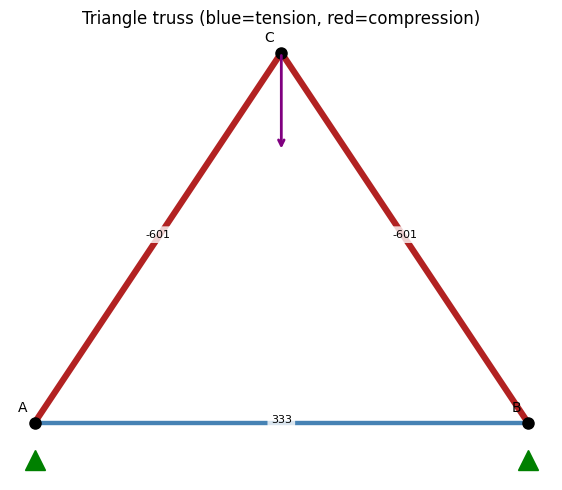

In [4]:
def draw_truss(joints, members, member_forces, supports, loads, title, ax):
    for a, c in members:
        xa, ya = joints[a]; xc, yc = joints[c]
        F = member_forces[f'{a}-{c}']
        color = 'firebrick' if F < -1e-6 else ('steelblue' if F > 1e-6 else 'gray')
        lw = 1.5 + min(abs(F) / 200, 4)
        ax.plot([xa, xc], [ya, yc], color=color, lw=lw, zorder=2)
        mx, my = (xa+xc)/2, (ya+yc)/2
        ax.annotate(f'{F:.0f}', (mx, my), fontsize=8, ha='center',
                    bbox=dict(boxstyle='round', fc='white', ec='none', alpha=0.8))
    for name, (x, y) in joints.items():
        ax.plot(x, y, 'ko', ms=8, zorder=3)
        ax.annotate(name, (x, y), textcoords='offset points', xytext=(-12, 8), fontsize=10)
    for j in supports:
        x, y = joints[j]
        ax.plot(x, y - 0.3, '^', color='green', ms=14, zorder=3)
    for j, (fx, fy) in loads.items():
        x, y = joints[j]
        ax.annotate('', xy=(x, y - 0.8), xytext=(x, y),
                    arrowprops=dict(arrowstyle='->', color='purple', lw=2))
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')

fig, ax = plt.subplots(figsize=(7, 5))
draw_truss(tri['joints'], tri['members'], tri['member_forces'], ['A', 'B'], tri['loads'],
           'Triangle truss (blue=tension, red=compression)', ax)
plt.tight_layout()
plt.savefig('statics_truss_triangle.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Zero-Force-Member Truss

Pin at A(0,0), roller at C(8,0), load $P$ at apex D(4,3), with an
unloaded midspan joint B(4,0) connected by a vertical member BD.
$F_{BD}=0$ follows from joint B's equilibrium ALONE (two horizontal
members and one vertical member, no external load) -- a classic,
sign-convention-independent structural result.


In [5]:
zfm = st.zero_force_member_truss_example(P=1000.0)
print('reactions:', zfm['reactions'])
print('member forces:', zfm['member_forces'])
print('classification:', st.classify_forces(zfm['member_forces']))

eq2 = st.verify_equilibrium_residuals(zfm['joints'], zfm['members'], zfm['member_forces'],
                                       zfm['reactions'], zfm['loads'])
print(f"\nequilibrium holds: {eq2['equilibrium_holds']}  (max residual: {eq2['max_residual']:.2e})")


reactions: {'Rx@A': 0.0, 'Ry@A': 500.0, 'Ry@C': 499.99999999999994}
member forces: {'A-B': 666.6666666666666, 'B-C': 666.6666666666666, 'A-D': -833.3333333333333, 'D-C': -833.3333333333333, 'B-D': 0.0}
classification: {'A-B': 'tension (666.667)', 'B-C': 'tension (666.667)', 'A-D': 'compression (833.333)', 'D-C': 'compression (833.333)', 'B-D': 'zero-force member'}

equilibrium holds: True  (max residual: 1.14e-13)


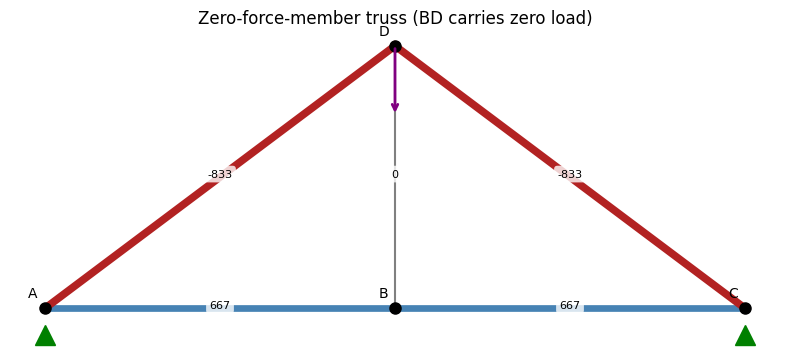

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
draw_truss(zfm['joints'], zfm['members'], zfm['member_forces'], ['A', 'C'], zfm['loads'],
           'Zero-force-member truss (BD carries zero load)', ax)
plt.tight_layout()
plt.savefig('statics_truss_zero_force.png', dpi=100, bbox_inches='tight')
plt.show()


In [7]:
# confirm F_BD stays exactly zero across a range of load magnitudes --
# not a coincidence at one specific P
for P_test in (100.0, 1000.0, 5000.0, 25000.0):
    result = st.zero_force_member_truss_example(P=P_test)
    print(f'P={P_test:>8.1f}: F_BD = {result["member_forces"]["B-D"]:.2e}')


P=   100.0: F_BD = 0.00e+00
P=  1000.0: F_BD = 0.00e+00
P=  5000.0: F_BD = 0.00e+00
P= 25000.0: F_BD = 0.00e+00


## 4. Method of Sections: An Independent Cross-Check (That Caught a Real Bug)

`method_of_sections_DC` cuts through AD, DC, BD and takes moments about
B (which lies on AB's and BD's lines of action, eliminating them),
solving for $F_{DC}$ from ONE equation -- completely independent of the
method-of-joints linear solve above.

**While building this module, the first version of this function had the
tension-direction convention backwards** (assumed a cut member's tension
pulls the free body AWAY from the other end, when it actually pulls
TOWARD it) -- caught immediately because this cross-check disagreed in
SIGN with the method-of-joints answer, even though the magnitude matched
exactly. That's the entire value of having two independent methods.


In [8]:
F_DC_sections = st.method_of_sections_DC(zfm['joints'], zfm['reactions'], zfm['loads'], P_ref=1000.0)
F_DC_joints = zfm['member_forces']['D-C']
print(f'F_DC (method of sections): {F_DC_sections:.4f}')
print(f'F_DC (method of joints):   {F_DC_joints:.4f}')
print(f'agree: {abs(F_DC_sections - F_DC_joints) < 1e-6}')


F_DC (method of sections): -833.3333
F_DC (method of joints):   -833.3333
agree: True


## 5. Engineering Interpretation

- Section 1's determinacy check isn't a formality: an understatic truss
  ($m+r<2j$) is a MECHANISM (it can move without any member deforming),
  and `solve_method_of_joints` correctly refuses to even attempt a solve
  for one, since the linear system would be singular.
- Section 3's zero-force member is a genuinely useful design fact, not
  just a curiosity: real trusses are FULL of these (often included for
  buckling stability or to shorten an unsupported member length, not to
  carry primary load), and spotting them by inspection (as done here, from
  joint B's equilibrium alone) is a standard first step before solving a
  larger structure.
- Section 4's caught sign bug is the actual argument for doing statics
  with two independent methods rather than one: the magnitude matching
  (833.33 vs 833.33) would have looked like a near-miss rounding error if
  the two methods happened to disagree by a SMALL amount instead of an
  exact sign flip -- catching an EXACT sign flip immediately, rather than
  a subtle magnitude discrepancy, is what made this bug obvious.


## 6. Research Discussion

- `solve_method_of_joints`'s general linear-system assembly (not
  hand-derived per truss) should scale to larger, less symmetric
  structures where hand-verification isn't practical -- a natural
  follow-up is a bigger truss (e.g. a full Pratt or Warren bridge truss)
  where `verify_equilibrium_residuals` becomes the PRIMARY correctness
  check rather than a confirmation of hand work.
- `dgs.lagrangian_rigid_body` (if it exists in this repo) handles rigid-
  body DYNAMICS; this module is the static ($\ddot x=0$) special case of
  the same free-body-diagram methodology -- worth an explicit note
  connecting the two, since a truss under a suddenly-applied (not
  gradually-applied) load is exactly where the static analysis here stops
  being valid.
- Method of sections generalizes to cuts through MORE than 3 members if
  additional equilibrium equations (not just one moment equation) are
  available -- `method_of_sections_moment`'s general moment-summation
  utility could be extended to a two-equation (moment + one force
  equation) cut for a section where 3 unknowns can't all be eliminated by
  one clever point.


## 7. Possible Experiments

1. Build a bigger, less symmetric truss (6+ joints, no hand-verifiable
   closed form) and rely ENTIRELY on `verify_equilibrium_residuals` for
   correctness -- the real-world version of the workflow this notebook
   demonstrates on small, checkable examples.
2. Deliberately re-introduce the caught sign bug (flip `u_DC`'s direction
   back) and confirm `test_statics_truss.py`'s method-of-sections
   assertion catches it immediately -- a concrete regression test for the
   exact mistake this module's development hit.
3. Extend `zero_force_member_truss_example` with a SECOND unloaded
   midspan joint and confirm the same "vertical member, no load, two
   horizontal members" zero-force pattern repeats -- checking the general
   rule, not just this one instance.


## 8. Future Improvements

- `solve_method_of_joints` only supports 'pin', 'roller_x', 'roller_y'
  supports; a fixed (moment-resisting) support, needed for a frame rather
  than a pure truss, would need a genuinely different formulation (frames
  aren't pin-jointed two-force members).
- `method_of_sections_DC` is specific to the zero-force-member truss's
  geometry; a general method-of-sections utility (given an arbitrary cut
  line and up to 3 unknown members) would need to auto-select a moment
  point that eliminates 2 of the 3 unknowns, which isn't always possible
  for an arbitrary cut.
